In [1]:
options(warn = -1)
suppressMessages(require(Seurat))
suppressMessages(require(ggplot2))
suppressMessages(require(dplyr))
suppressMessages(require(reticulate))
suppressMessages(require(stringr))
suppressMessages(require(ggpubr))
suppressMessages(require(tidydr))
suppressMessages(require(CellTrek))
suppressMessages(require(CARD))
#devtools::load_all('../Cell2Spatial/')

In [15]:
source('modules/globalParams.R')
source('modules/utils.R')
source('modules/vis.R')
source('modules/reformatProjResNew.R')

In [3]:
brain.st <- readRDS('../0.data/HD/sp.obj.RDS')

In [4]:
brain.sc <- readRDS('../0.data/HD/sc.obj.RDS')

In [10]:
#' @title findClustersForSpData
#'
#' @description Find clusters for single-cell data based on Seurat object.
#' @param obj.seu Seurat object of ST data.
#' @param npcs Number of PCs for clustering. Default: 50.
#' @param res Resolution parameter for finding clusters. Default: 0.8.
#' @return Seurat object after clustering.

findClustersForSpData <- function(obj.seu, npcs = 30, res = 0.8, verbose = TRUE) {
    obj.seu <- obj.seu %>% SCTransform(assay = 'Spatial') %>%
        RunPCA(., verbose = verbose) %>%
        FindNeighbors(., reduction = "pca", verbose = verbose) %>%
        FindClusters(., verbose = verbose) %>%
        RunUMAP(., reduction = "pca", dims = 1:npcs, verbose = verbose)
    return(obj.seu)
}

In [11]:
brain.st <- findClustersForSpData(brain.st)

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 14417 by 50000

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells



  |======================================================================| 100%


Found 55 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 14417 genes



  |======================================================================| 100%


Computing corrected count matrix for 14417 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 4.629438 mins

Determine variable features

Place corrected count matrix in counts slot

Centering data matrix

Set default assay to SCT

PC_ 1 
Positive:  Camk2n1, Snap25, Olfm1, Nrgn, Ncdn, Uchl1, Calm3, Camk2a, Ptk2b, Nptxr 
	   Atp1b1, Eef1a2, Slc17a7, Cck, Ywhah, Arf3, Gpm6a, Sept5, Snrpn, Ywhag 
	   Scn1b, Snhg11, Atp2a2, Rasgrp1, mt-Co2, Map1b, Basp1, Hpca, Selenow, Rab6b 
Negative:  Ptgds, Plp1, Mbp, Mobp, Apod, Mal, Trf, Cldn11, Fth1, Mag 
	   Apoe, Ugt8a, Cnp, Car2, Gatm, Cryab, Atp1a2, Plekhb1, Sgk1, Tspan2 
	   Igf2, Qk, Gfap, Ermn, Sept4, Mog, Selenop, Ppp1r14a, Qdpr, Enpp2 
PC_ 2 
Positive:  Plp1, Mbp, Mobp, Mal, Trf, Fth1, Cldn11, Mag, Ugt8a, Cnp 
	   Gatm, Tspan2, Car2, Plekhb1, Ermn, Cryab, Sgk1, Sept4, Mog, Qdpr 
	   Ppp1r14a, Dbndd2, Bcas1, Pllp, Fa2h, Gjc3, Opalin, Sez6l2, Slain1, Efnb3 
Negative:  Ptgds, Igf2, Atp1a2, Apoe, Mgp, Slc6a20a, Igfbp2, Col1a2, Aldh1a2, Fn1 
	   Fmod, Aebp1, Slc13a4, Ogn, 

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 50000
Number of edges: 1470808

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8444
Number of communities: 15
Elapsed time: 71 seconds


19:52:01 UMAP embedding parameters a = 0.9922 b = 1.112

19:52:01 Read 50000 rows and found 30 numeric columns

19:52:01 Using Annoy for neighbor search, n_neighbors = 30

19:52:01 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

19:52:17 Writing NN index file to temp file /tmp/RtmpqMquzd/file59525623cbf8

19:52:17 Searching Annoy index using 1 thread, search_k = 3000

19:53:09 Annoy recall = 100%

19:53:12 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

19:53:17 Initializing from normalized Laplacian + noise (using irlba)

19:53:26 Commencing optimization for 200 epochs, with 2394226 positive edges

19:53:54 Optimization finished



In [353]:
cell.colors <- randomcoloR::distinctColorPalette(length(levels(brain.st)))  %>% `names<-`(levels(brain.st))

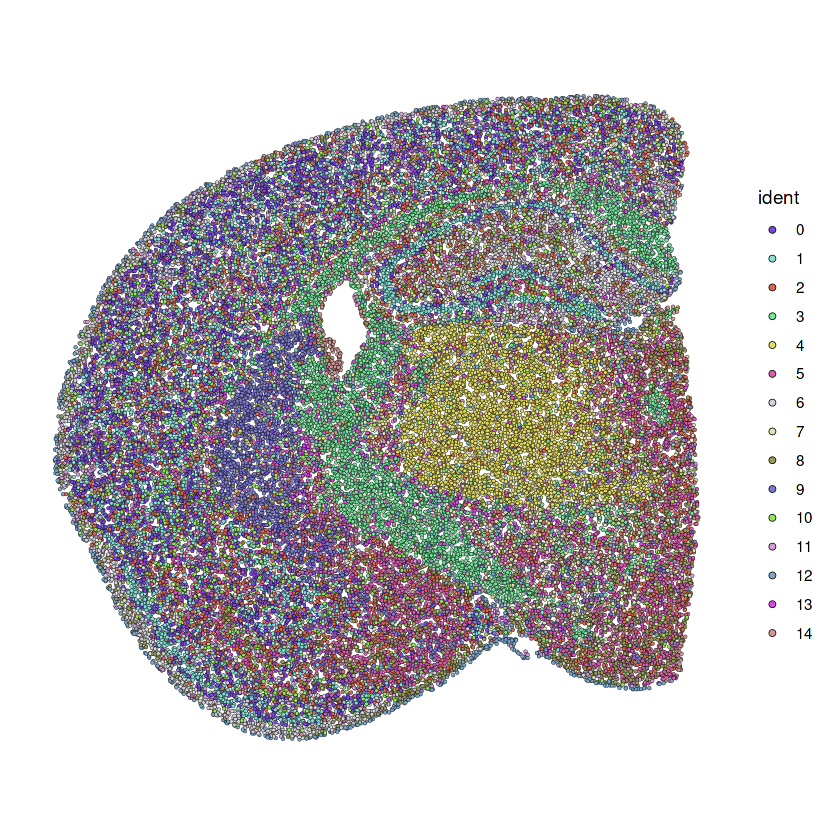

In [196]:
SpatialDimPlot(brain.st, pt.size.factor = 1.0, cols = cell.colors)
ggsave(file.path('Hd.true.pdf'), width = 6, height = 6)

In [380]:
f.ctypes <- levels(brain.st)
gps <- lapply(f.ctypes, function(ct) {
    h.cells <- subset(brain.st, idents = ct) %>% Cells
    #obj.sub <- seurat.res[, h.cells]
    SpatialPlot(brain.st, cells.highlight = h.cells, pt.size.factor = 1.0, stroke = NA, cols.highlight = c('red', 'grey90')) + ggtitle(ct) + NoLegend() 
    #SpatialPlot(seurat.res, cells.highlight = h.cells, group.by = 'predicted.id', cols = cell.colors[ct], pt.size.factor = 1.8, stroke = NA, alpha = c(0.5, 1)) + ggtitle(ct) + NoLegend()  
})

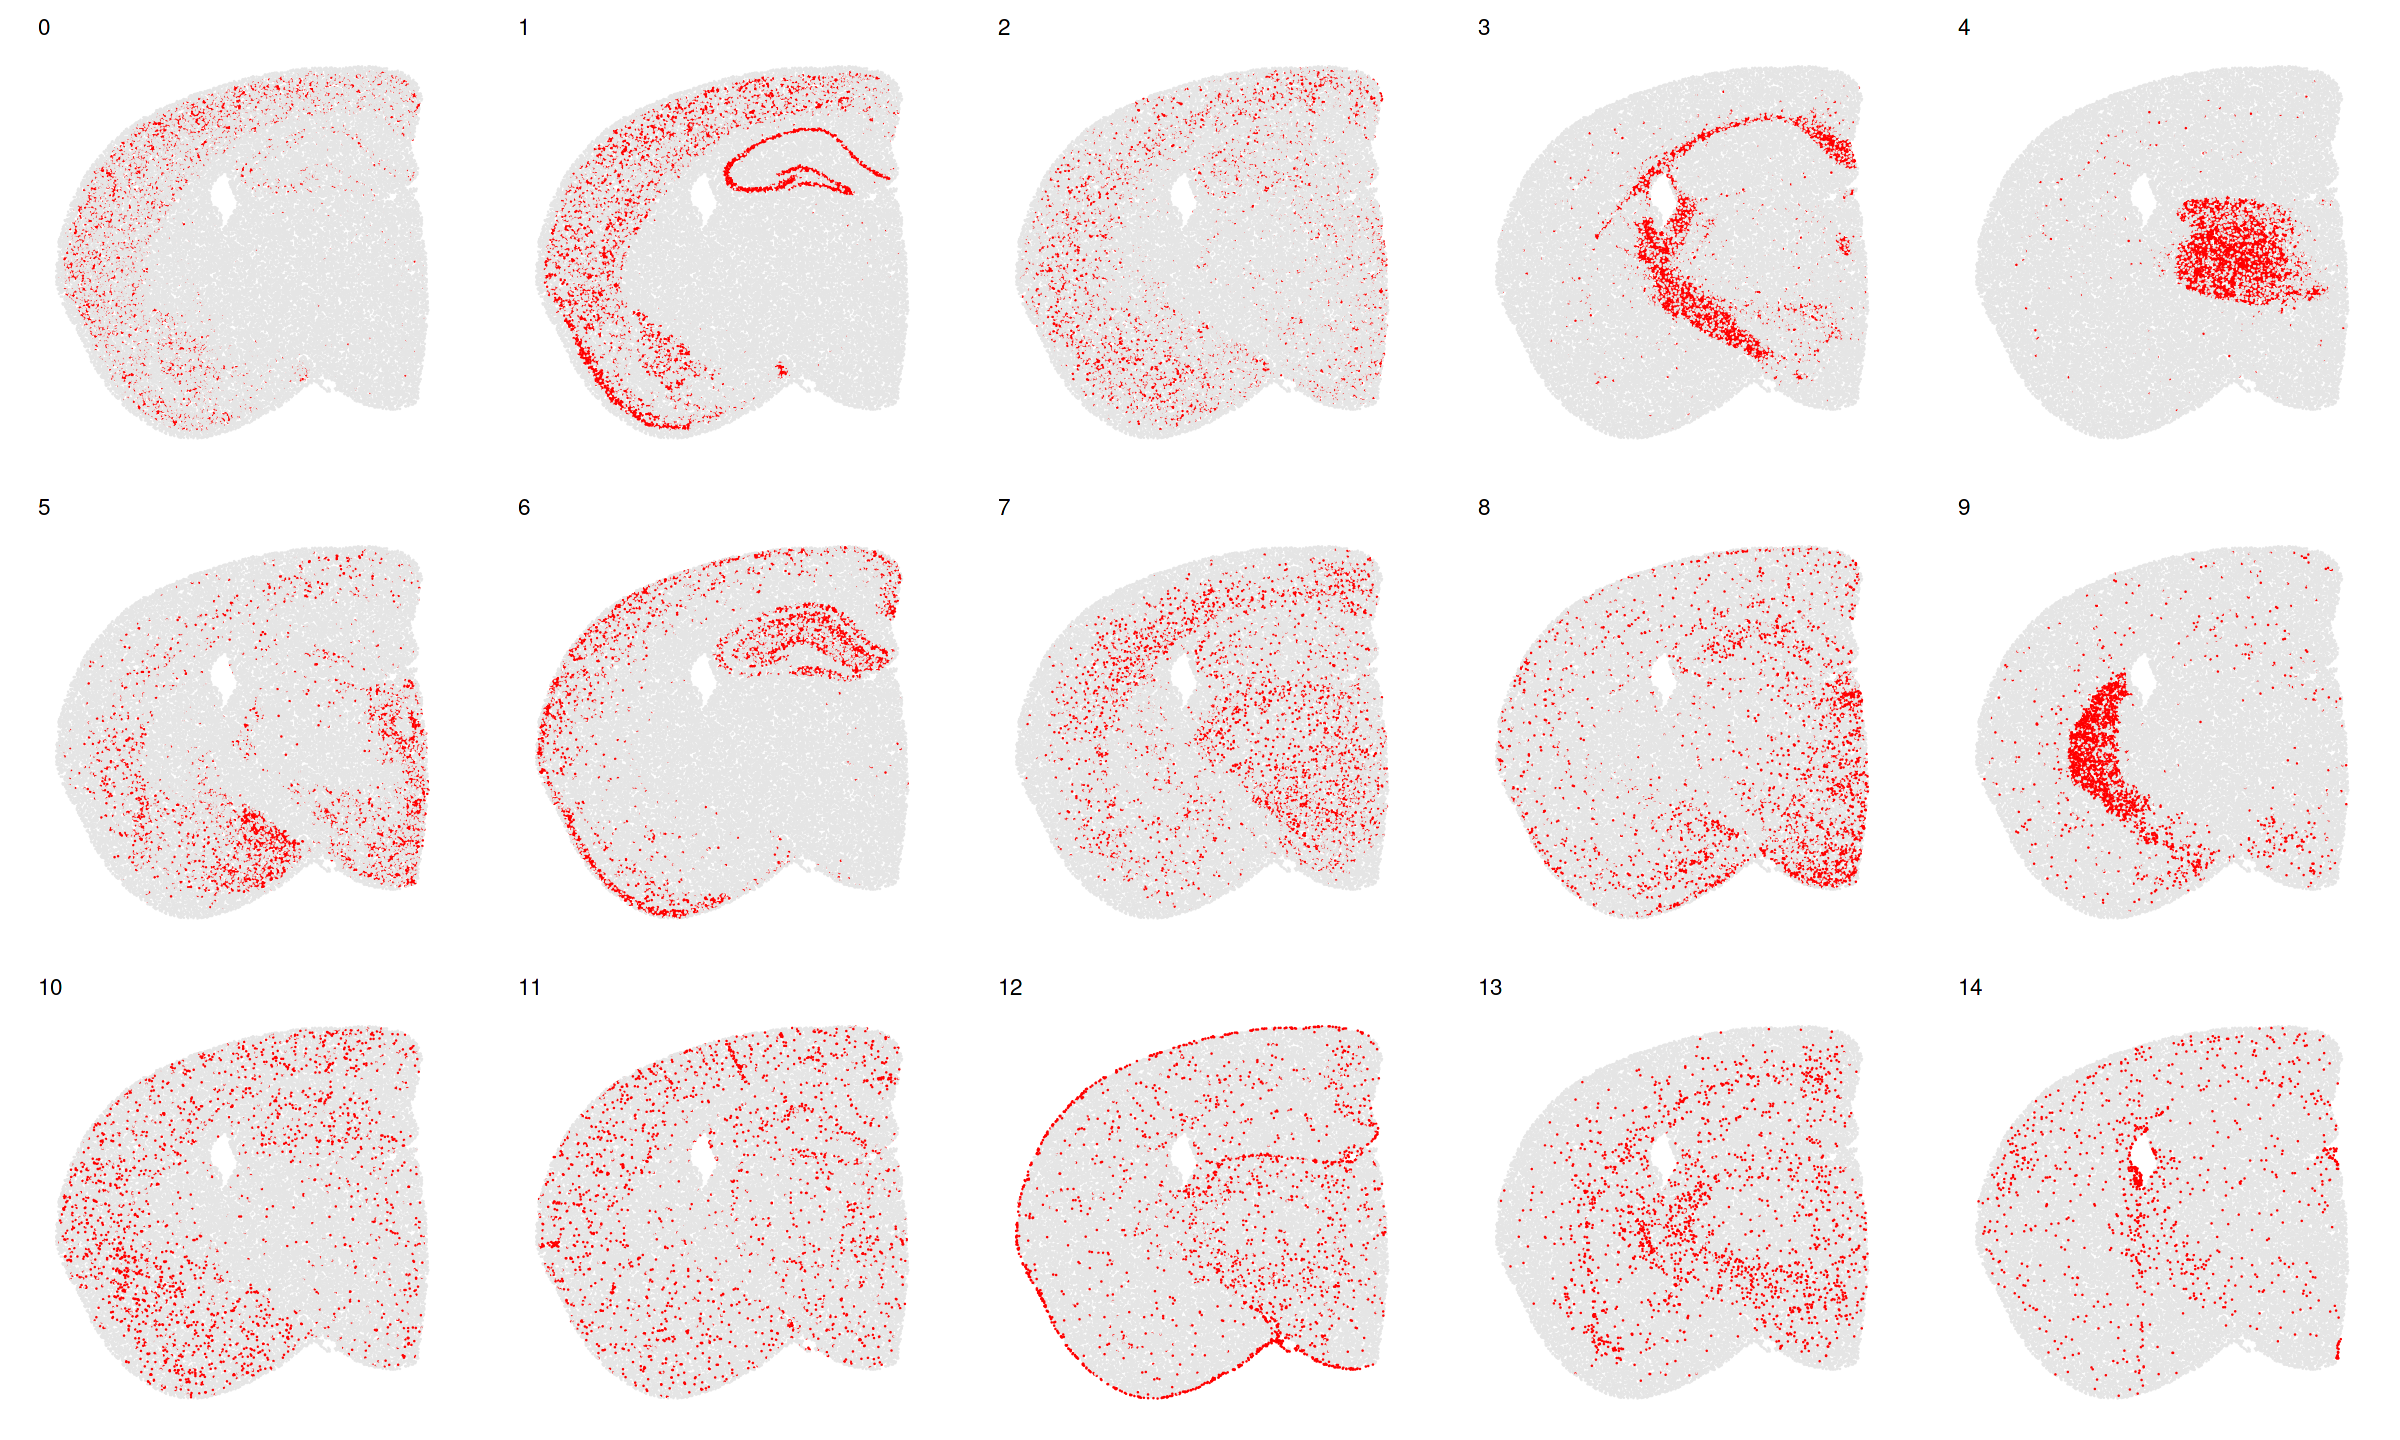

In [381]:
options(repr.plot.width = 20, repr.plot.height = 12)
ggarrange(plotlist = gps, nrow = 3, ncol = 5)
ggsave(file.path('../2.results/HD/', 'true.split.UMAP.pdf'), width = 20, height = 12)
ggsave(file.path('../2.results/HD/', 'true.split.UMAP.eps'), width = 20, height = 12)

In [99]:
brain.sc$CellTypeNew <- Idents(brain.st)
saveRDS(brain.sc, file = '../0.data/HD//sc.obj.New.RDS')

In [233]:
cytospace <- forCytoSpace('../2.results/HD/cytospace/', brain.sc, brain.st)

In [234]:
cytospace$CellTypeNew <- Idents(brain.st)[cytospace$SpotID]

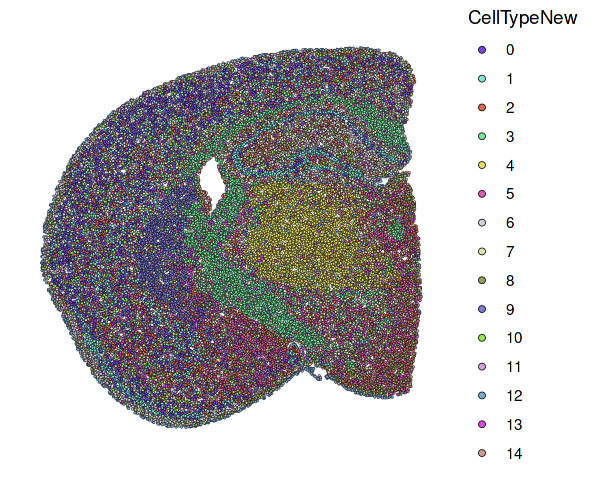

In [236]:
SpatialPlot(cytospace, group.by = 'CellTypeNew', cols = cell.colors, pt.size.factor = 1.0)

In [257]:
cytospace@meta.data$Cluster <- brain.st$CellType[cytospace$SpotID]

In [258]:
cyto.acc <- lapply(unique(cytospace@meta.data$Cluster), function(idx) {
    tmp.dx <- subset(cytospace, Cluster==idx)
    sum(tmp.dx$OriginalCID == tmp.dx$SpotID) / dim(tmp.dx)[2]
}) %>% unlist %>% { cbind.data.frame(Acc = ., Tool = 'CytoSPACE', Idx = unique(cytospace@meta.data$Cluster)) }

In [371]:
cell2spatial <- readRDS('../2.results/HD/HD.cell2spatial.RDS')

In [372]:
cell2spatial$ID <- (Idents(brain.st) %>% as.vector %>% `names<-`(colnames(brain.st)))[as.vector(cell2spatial$SpotName)] %>% `names<-`(rownames(cell2spatial@meta.data))
cell2spatial$ID <- factor(cell2spatial$ID, levels = levels(brain.st))

In [373]:
levels(brain.st)

[1] "0"  "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14"

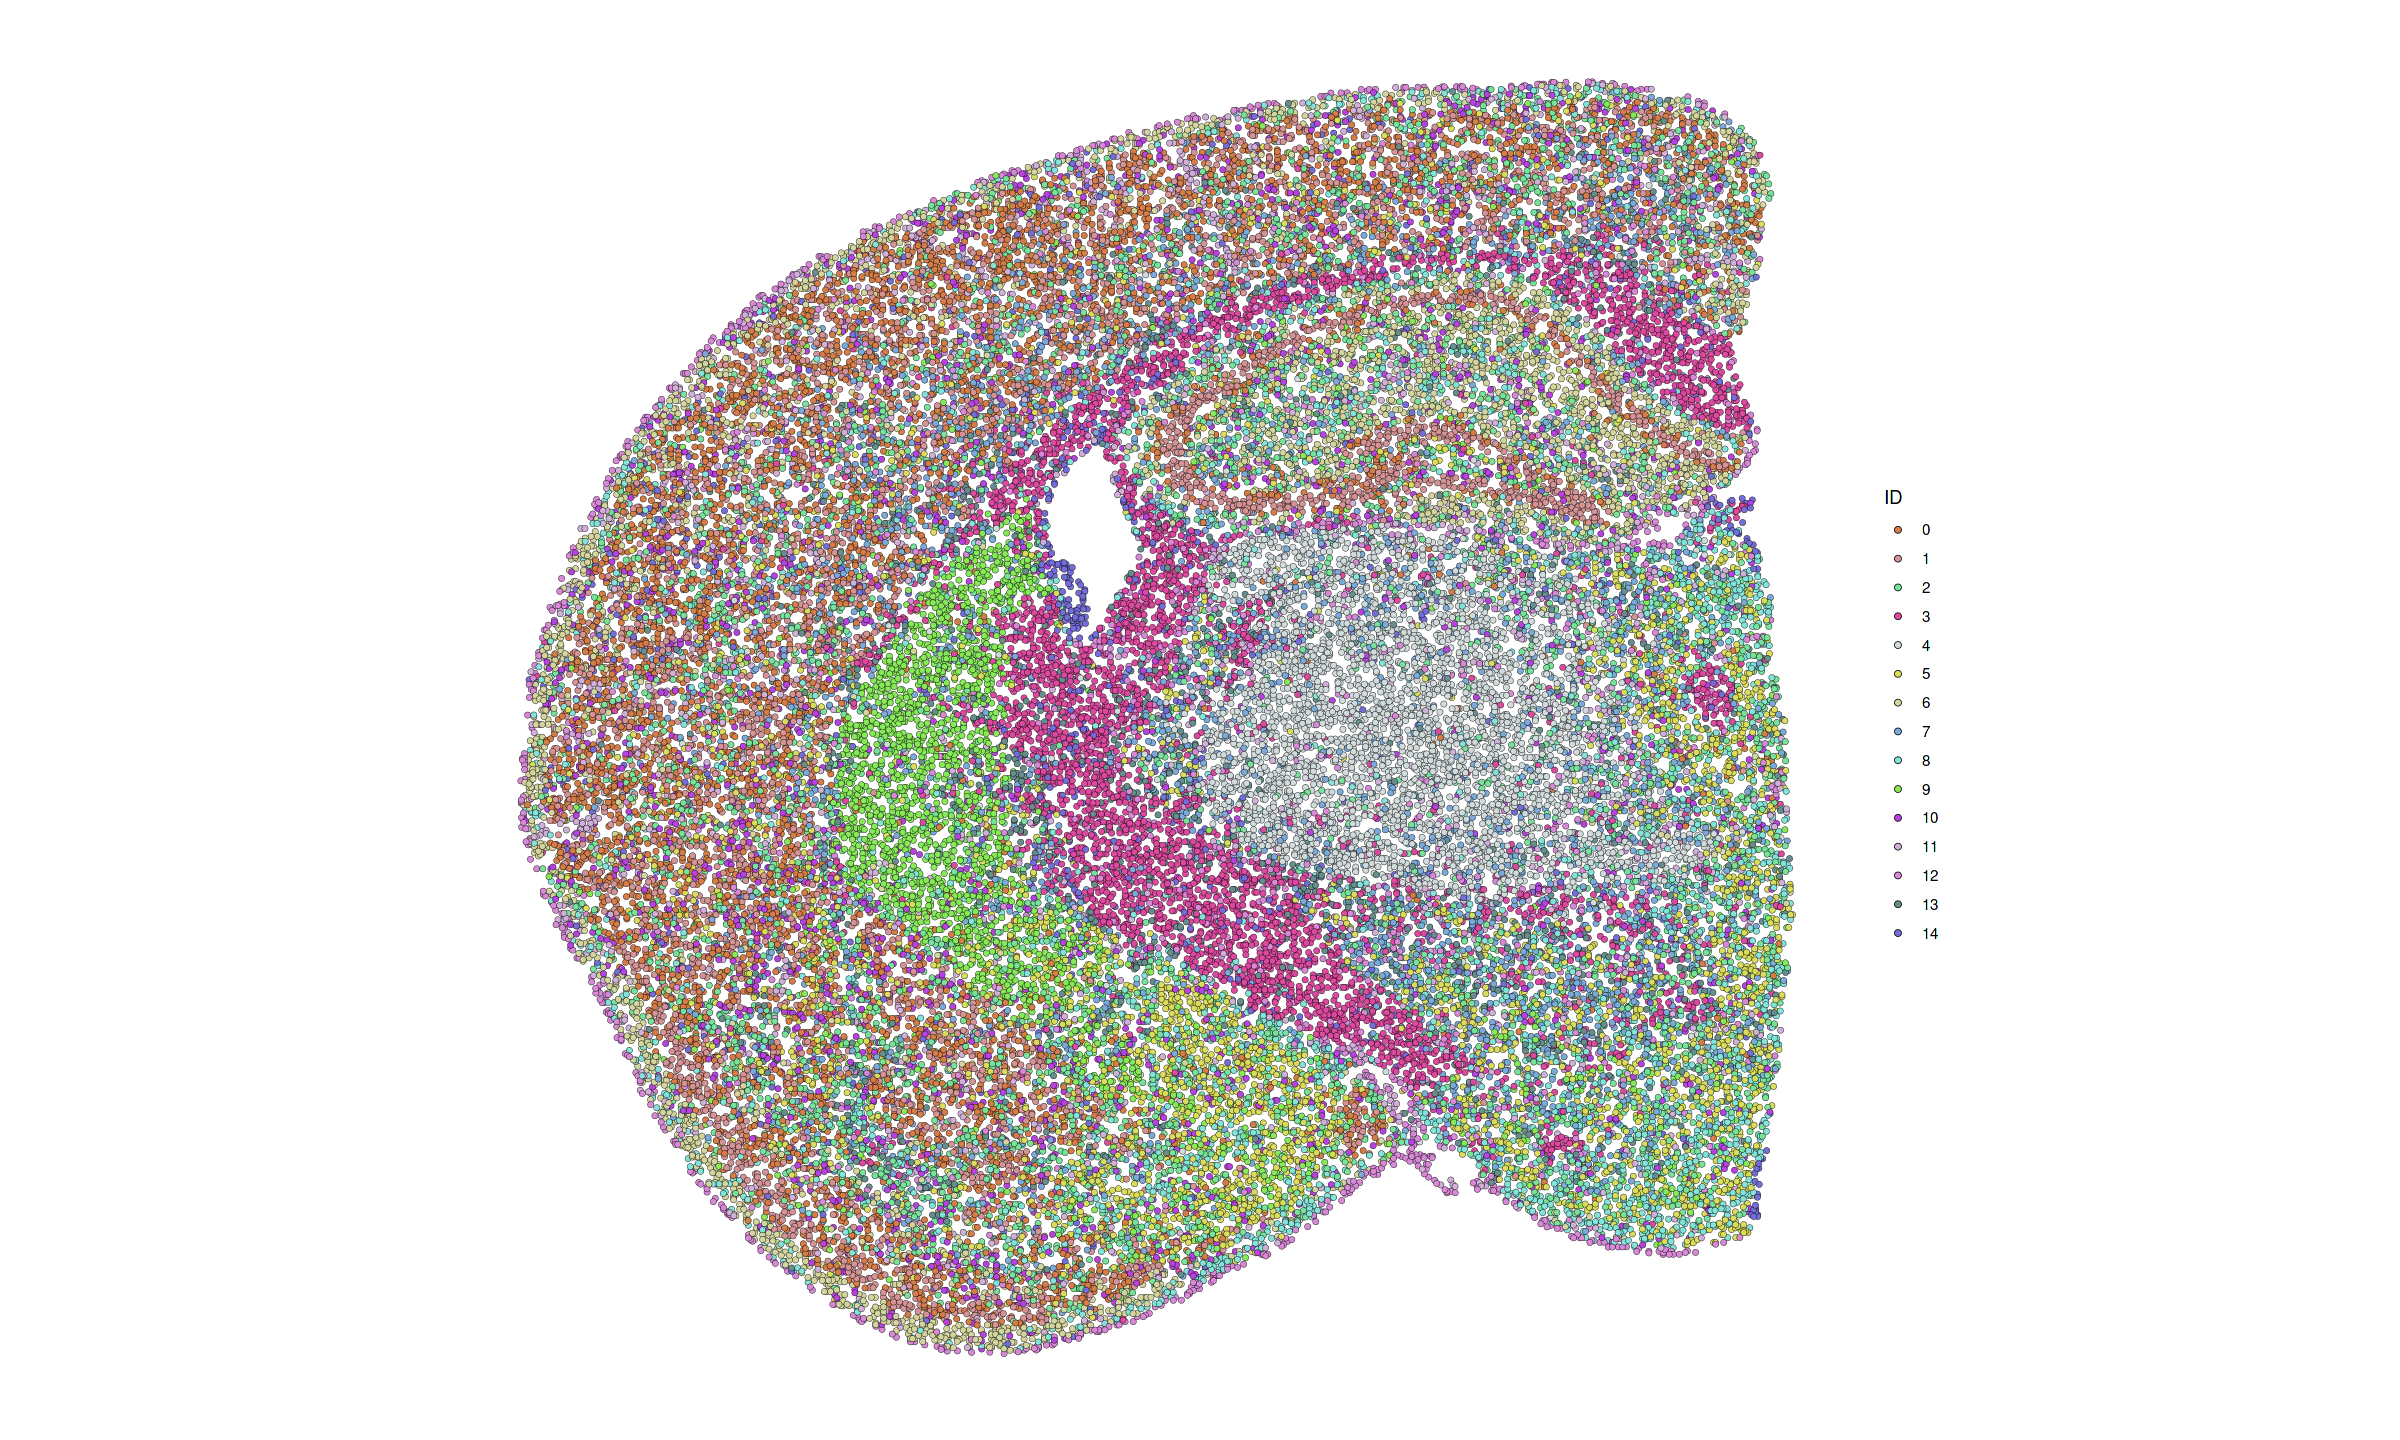

In [374]:
SpatialPlot(cell2spatial, group.by = 'ID', cols = cell.colors, pt.size.factor = 1.0)
ggsave(file.path('Hd.ours.pdf'), width = 6, height = 6)

In [375]:
cell2spatial@meta.data$Cluster <- brain.st$CellType[cell2spatial$SpotName]

In [376]:
cell2spatial.acc <- lapply(unique(cell2spatial@meta.data$Cluster), function(idx) {
    tmp.dx <- subset(cell2spatial, Cluster==idx)
    sum(tmp.dx$Cell == tmp.dx$SpotName) / dim(tmp.dx)[2]
}) %>% unlist %>% { cbind.data.frame(Acc = ., Tool = 'Cell2Spatial', Idx = unique(cell2spatial@meta.data$Cluster)) }

In [377]:
cell2spatial.sub <- subset(cell2spatial, orig.ident != 'Pseudo')
f.ctypes <- cell2spatial.sub$ID %>% unique
subset(cell2spatial)
gps <- lapply(f.ctypes, function(ct) {
    h.cells <- subset(cell2spatial.sub, ID == ct) %>% Cells
    #obj.sub <- seurat.res[, h.cells]
    SpatialPlot(cell2spatial.sub, cells.highlight = h.cells, pt.size.factor = 1.2, stroke = NA, cols.highlight = c('red', 'grey90')) + ggtitle(ct) + NoLegend() 
    #SpatialPlot(seurat.res, cells.highlight = h.cells, group.by = 'predicted.id', cols = cell.colors[ct], pt.size.factor = 1.8, stroke = NA, alpha = c(0.5, 1)) + ggtitle(ct) + NoLegend()  
})

An object of class Seurat 
14417 features across 50000 samples within 1 assay 
Active assay: Spatial (14417 features, 0 variable features)
 1 image present: image

In [1]:
options(repr.plot.width = 20, repr.plot.height = 12)
gp <- ggarrange(plotlist = gps, nrow = 3, ncol = 5)
ggsave(file.path('../2.results/HD/', 'cell2spatial.split.UMAP.pdf'), width = 20, height = 12)
ggsave(file.path('../2.results/HD/', 'cell2spatial.split.UMAP.eps'), width = 20, height = 12)